In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('IPL.csv')
print(df.shape)
print(df.head())
print(df.columns)

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\3392812653.py:5: DtypeWarning: Columns (0: review_batter, 1: team_reviewed, 2: review_decision, 3: umpire, 4: season, 5: superover_winner, 6: result_type, 7: method, 8: event_match_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


(278205, 64)
   Unnamed: 0  match_id        date match_type             event_name  \
0      131970    335982  2008-04-18        T20  Indian Premier League   
1      131971    335982  2008-04-18        T20  Indian Premier League   
2      131972    335982  2008-04-18        T20  Indian Premier League   
3      131973    335982  2008-04-18        T20  Indian Premier League   
4      131974    335982  2008-04-18        T20  Indian Premier League   

   innings           batting_team                 bowling_team  over  ball  \
0        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     1   
1        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     2   
2        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     3   
3        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     3   
4        1  Kolkata Knight Riders  Royal Challengers Bangalore     0     4   

   ...  team_runs team_balls  team_wicket  new_batter  batter_runs  \
0  ...   

In [2]:
print(df.columns.tolist())

['Unnamed: 0', 'match_id', 'date', 'match_type', 'event_name', 'innings', 'batting_team', 'bowling_team', 'over', 'ball', 'ball_no', 'batter', 'bat_pos', 'runs_batter', 'balls_faced', 'bowler', 'valid_ball', 'runs_extras', 'runs_total', 'runs_bowler', 'runs_not_boundary', 'extra_type', 'non_striker', 'non_striker_pos', 'wicket_kind', 'player_out', 'fielders', 'runs_target', 'review_batter', 'team_reviewed', 'review_decision', 'umpire', 'umpires_call', 'player_of_match', 'match_won_by', 'win_outcome', 'toss_winner', 'toss_decision', 'venue', 'city', 'day', 'month', 'year', 'season', 'gender', 'team_type', 'superover_winner', 'result_type', 'method', 'balls_per_over', 'overs', 'event_match_no', 'stage', 'match_number', 'team_runs', 'team_balls', 'team_wicket', 'new_batter', 'batter_runs', 'batter_balls', 'bowler_wicket', 'batting_partners', 'next_batter', 'striker_out']


C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2535953303.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r')


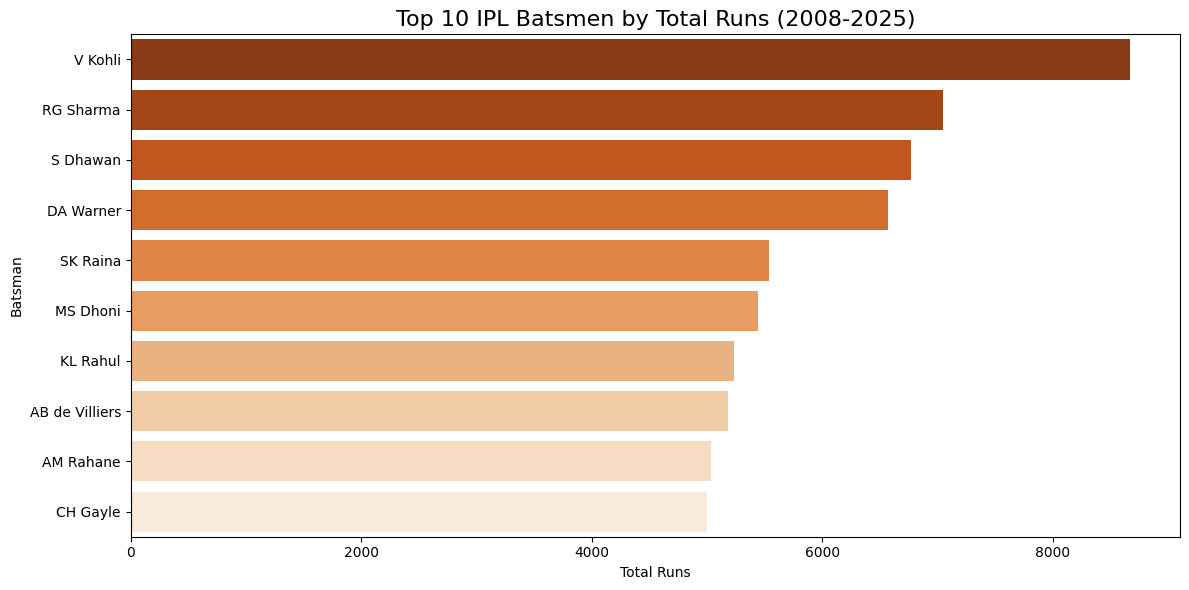

In [3]:
# Top 10 Batsmen by Total Runs
top_batsmen = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r')
plt.title('Top 10 IPL Batsmen by Total Runs (2008-2025)', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.show()

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\1617124385.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Blues_r')


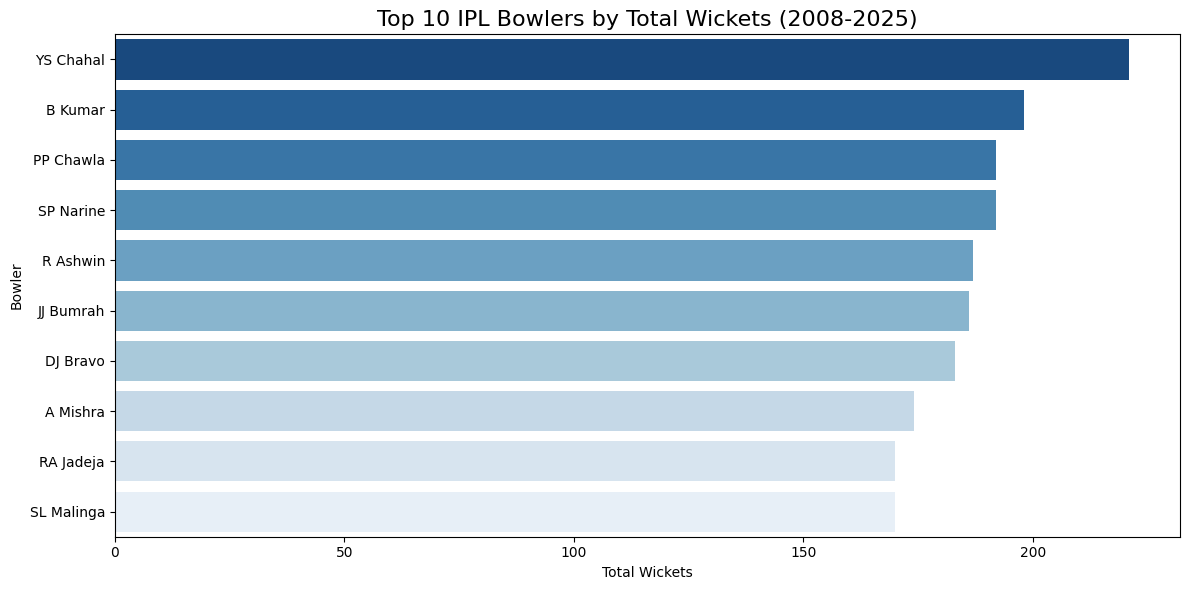

In [4]:
# Top 10 Bowlers by Total Wickets
top_bowlers = df[df['bowler_wicket'] == 1].groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Blues_r')
plt.title('Top 10 IPL Bowlers by Total Wickets (2008-2025)', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.show()

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\880650027.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='Greens_r')


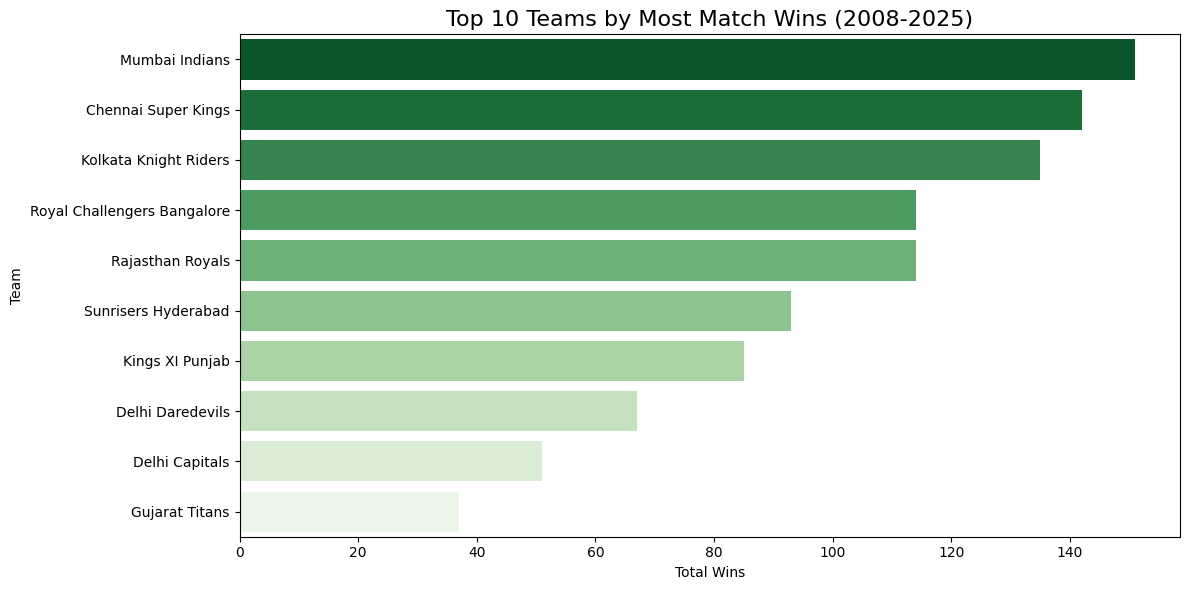

In [5]:
# Team with Most Match Wins
team_wins = df.groupby('match_id')['match_won_by'].first().value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='Greens_r')
plt.title('Top 10 Teams by Most Match Wins (2008-2025)', fontsize=16)
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2964546953.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=['Toss Winner Lost', 'Toss Winner Won'], y=toss_impact.values, palette='Purples_r')


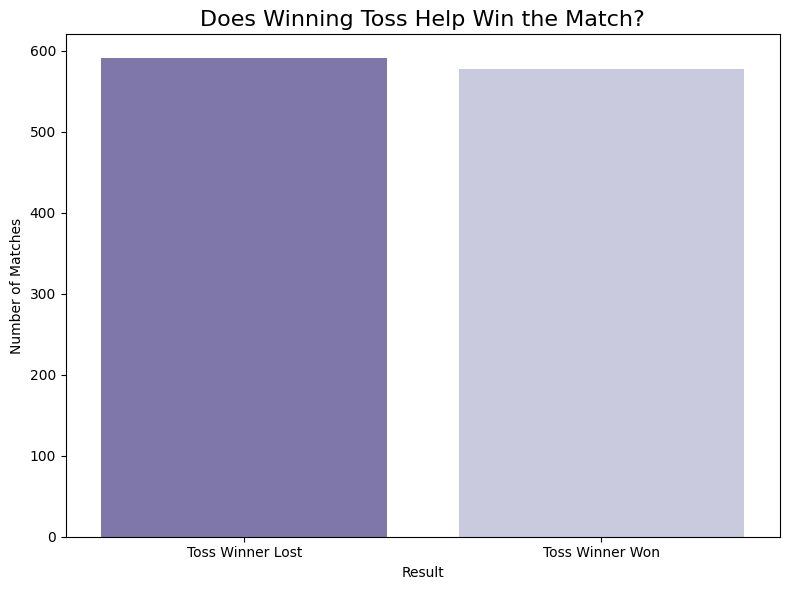

In [6]:
# Toss Impact on Winning
toss_win = df.groupby('match_id')[['toss_winner', 'match_won_by']].first()
toss_win['toss_helped'] = toss_win['toss_winner'] == toss_win['match_won_by']
toss_impact = toss_win['toss_helped'].value_counts()

plt.figure(figsize=(8,6))
sns.barplot(x=['Toss Winner Lost', 'Toss Winner Won'], y=toss_impact.values, palette='Purples_r')
plt.title('Does Winning Toss Help Win the Match?', fontsize=16)
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.show()

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('IPL.csv')
print(df.shape)

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2163557537.py:5: DtypeWarning: Columns (0: review_batter, 1: team_reviewed, 2: review_decision, 3: umpire, 4: season, 5: superover_winner, 6: result_type, 7: method, 8: event_match_no) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('IPL.csv')


(278205, 64)


C:\Users\srich\AppData\Local\Temp\ipykernel_20472\1281857787.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=season_runs.index, y=season_runs.values, palette='Reds_r', errorbar=None)


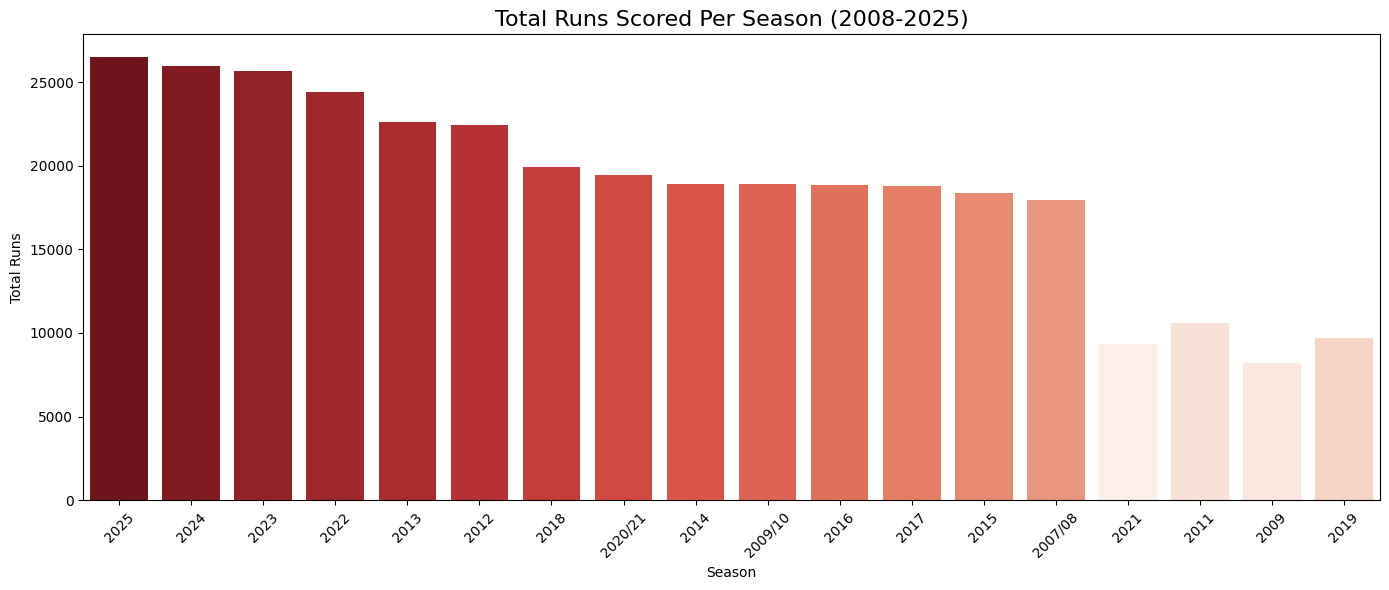

In [10]:
# Total Runs Scored Per Season
season_runs = df.groupby('season')['runs_total'].sum().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=season_runs.index, y=season_runs.values, palette='Reds_r', errorbar=None)
plt.title('Total Runs Scored Per Season (2008-2025)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [15]:
# Fix team names
team_name_map = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Deccan Chargers': 'Sunrisers Hyderabad',
    'Rising Pune Supergiant': 'Rising Pune Supergiants',
    'Pune Warriors': 'Pune Warriors India',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Gujarat Lions': 'Gujarat Titans',
    'Rising Pune Supergiants': 'Rising Pune Supergiants',
}

df['batting_team'] = df['batting_team'].replace(team_name_map)
df['bowling_team'] = df['bowling_team'].replace(team_name_map)
df['match_won_by'] = df['match_won_by'].replace(team_name_map)
df['toss_winner'] = df['toss_winner'].replace(team_name_map)

print("Team names fixed!")

Team names fixed!


C:\Users\srich\AppData\Local\Temp\ipykernel_20472\4115039642.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=sixes.values, y=sixes.index, palette='Purples_r', errorbar=None)


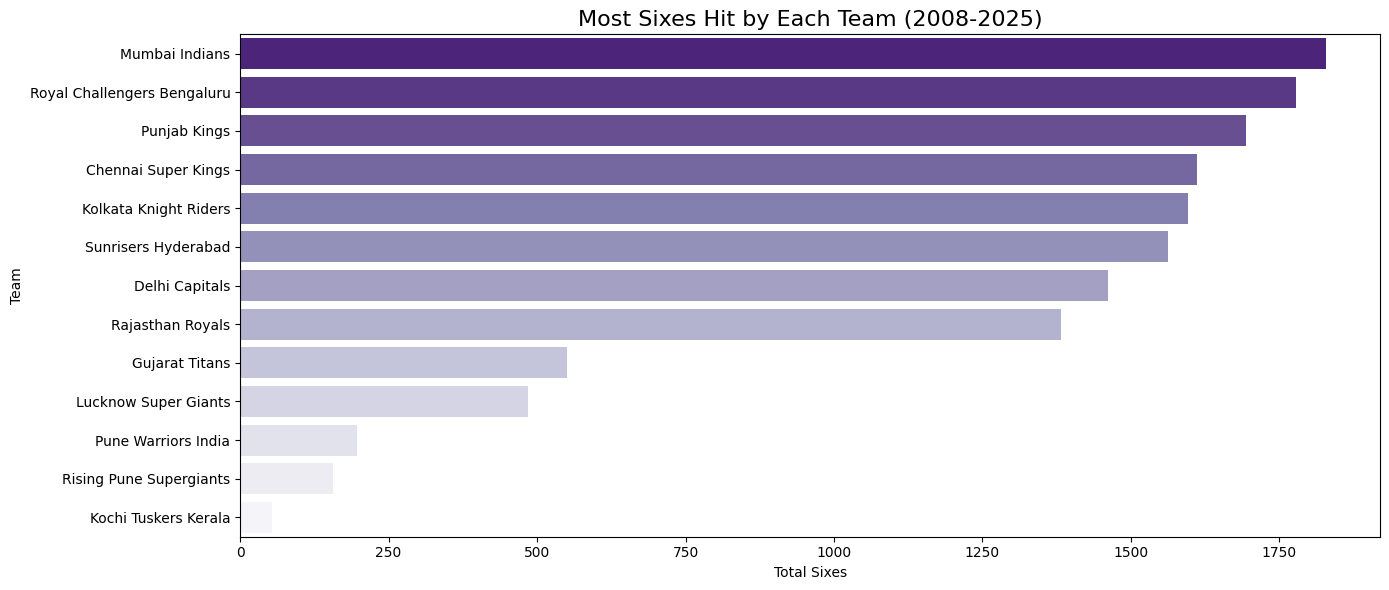

In [16]:
# Most Sixes Hit by Each Team
sixes = df[df['runs_batter'] == 6].groupby('batting_team')['runs_batter'].count().sort_values(ascending=False)

plt.figure(figsize=(14,6))
sns.barplot(x=sixes.values, y=sixes.index, palette='Purples_r', errorbar=None)
plt.title('Most Sixes Hit by Each Team (2008-2025)', fontsize=16)
plt.xlabel('Total Sixes')
plt.ylabel('Team')
plt.tight_layout()
plt.show()

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\551598039.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=potm.values, y=potm.index, palette='YlOrRd', errorbar=None)


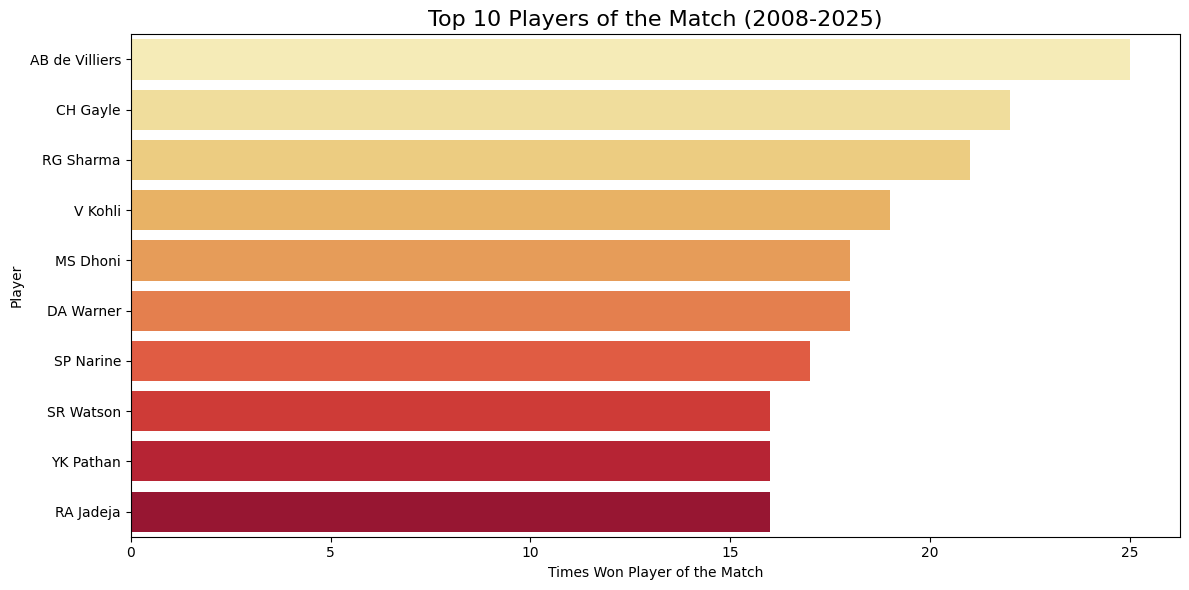

In [17]:
# Top 10 Players of the Match
potm = df.groupby('match_id')['player_of_match'].first().value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=potm.values, y=potm.index, palette='YlOrRd', errorbar=None)
plt.title('Top 10 Players of the Match (2008-2025)', fontsize=16)
plt.xlabel('Times Won Player of the Match')
plt.ylabel('Player')
plt.tight_layout()
plt.show()

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\340538798.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=venues.values, y=venues.index, palette='coolwarm', errorbar=None)


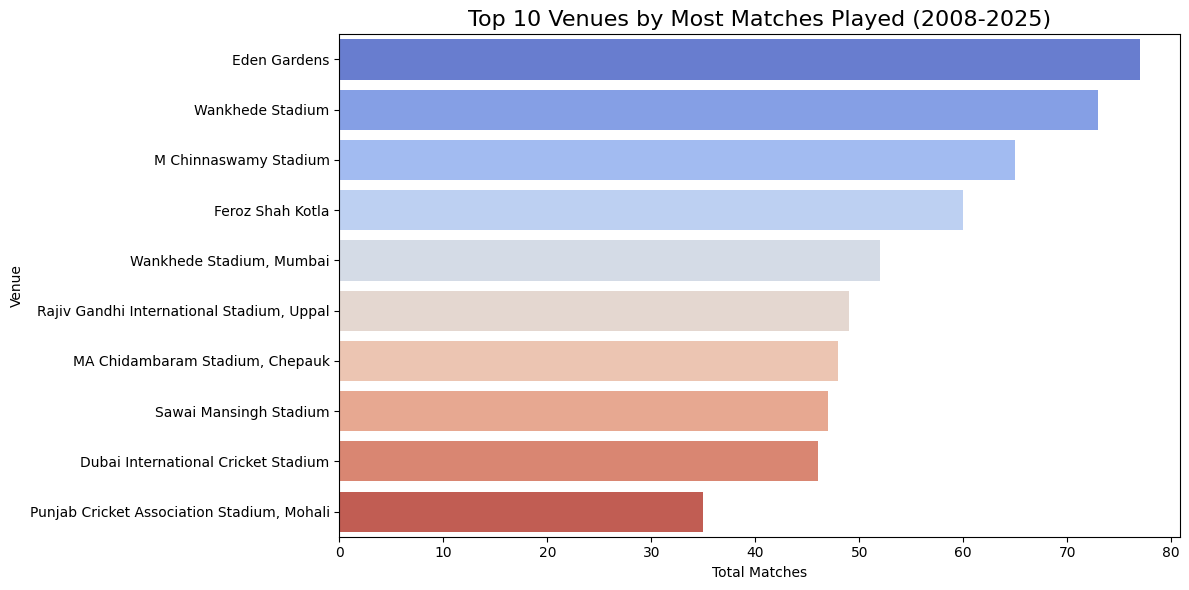

In [18]:
# Top 10 Venues by Most Matches Played
venues = df.groupby('match_id')['venue'].first().value_counts().head(10)

plt.figure(figsize=(12,6))
sns.barplot(x=venues.values, y=venues.index, palette='coolwarm', errorbar=None)
plt.title('Top 10 Venues by Most Matches Played (2008-2025)', fontsize=16)
plt.xlabel('Total Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.show()

In [19]:
import os
os.makedirs('charts', exist_ok=True)

# Chart 1 - Top 10 Batsmen
top_batsmen = df.groupby('batter')['runs_batter'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r', errorbar=None)
plt.title('Top 10 IPL Batsmen by Total Runs (2008-2025)', fontsize=16)
plt.xlabel('Total Runs')
plt.ylabel('Batsman')
plt.tight_layout()
plt.savefig('charts/top_batsmen.png')
plt.close()

# Chart 2 - Top 10 Bowlers
top_bowlers = df[df['bowler_wicket'] == 1].groupby('bowler')['bowler_wicket'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Blues_r', errorbar=None)
plt.title('Top 10 IPL Bowlers by Total Wickets (2008-2025)', fontsize=16)
plt.xlabel('Total Wickets')
plt.ylabel('Bowler')
plt.tight_layout()
plt.savefig('charts/top_bowlers.png')
plt.close()

# Chart 3 - Team Wins
team_wins = df.groupby('match_id')['match_won_by'].first().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=team_wins.values, y=team_wins.index, palette='Greens_r', errorbar=None)
plt.title('Top 10 Teams by Most Match Wins (2008-2025)', fontsize=16)
plt.xlabel('Total Wins')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('charts/team_wins.png')
plt.close()

# Chart 4 - Toss Impact
toss_win = df.groupby('match_id')[['toss_winner', 'match_won_by']].first()
toss_win['toss_helped'] = toss_win['toss_winner'] == toss_win['match_won_by']
toss_impact = toss_win['toss_helped'].value_counts()
plt.figure(figsize=(8,6))
sns.barplot(x=['Toss Winner Lost', 'Toss Winner Won'], y=toss_impact.values, palette='Purples_r', errorbar=None)
plt.title('Does Winning Toss Help Win the Match?', fontsize=16)
plt.xlabel('Result')
plt.ylabel('Number of Matches')
plt.tight_layout()
plt.savefig('charts/toss_impact.png')
plt.close()

# Chart 5 - Runs Per Season
season_runs = df.groupby('season')['runs_total'].sum().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=season_runs.index, y=season_runs.values, palette='Reds_r', errorbar=None)
plt.title('Total Runs Scored Per Season (2008-2025)', fontsize=16)
plt.xlabel('Season')
plt.ylabel('Total Runs')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('charts/runs_per_season.png')
plt.close()

# Chart 6 - Most Sixes by Team
sixes = df[df['runs_batter'] == 6].groupby('batting_team')['runs_batter'].count().sort_values(ascending=False)
plt.figure(figsize=(14,6))
sns.barplot(x=sixes.values, y=sixes.index, palette='Purples_r', errorbar=None)
plt.title('Most Sixes Hit by Each Team (2008-2025)', fontsize=16)
plt.xlabel('Total Sixes')
plt.ylabel('Team')
plt.tight_layout()
plt.savefig('charts/most_sixes.png')
plt.close()

# Chart 7 - Player of the Match
potm = df.groupby('match_id')['player_of_match'].first().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=potm.values, y=potm.index, palette='YlOrRd', errorbar=None)
plt.title('Top 10 Players of the Match (2008-2025)', fontsize=16)
plt.xlabel('Times Won Player of the Match')
plt.ylabel('Player')
plt.tight_layout()
plt.savefig('charts/player_of_match.png')
plt.close()

# Chart 8 - Top Venues
venues = df.groupby('match_id')['venue'].first().value_counts().head(10)
plt.figure(figsize=(12,6))
sns.barplot(x=venues.values, y=venues.index, palette='coolwarm', errorbar=None)
plt.title('Top 10 Venues by Most Matches Played (2008-2025)', fontsize=16)
plt.xlabel('Total Matches')
plt.ylabel('Venue')
plt.tight_layout()
plt.savefig('charts/top_venues.png')
plt.close()

print("All 8 charts saved in charts folder!")

C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2637783105.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_batsmen.values, y=top_batsmen.index, palette='Oranges_r', errorbar=None)
C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2637783105.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_bowlers.values, y=top_bowlers.index, palette='Blues_r', errorbar=None)
C:\Users\srich\AppData\Local\Temp\ipykernel_20472\2637783105.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=team_wins.values, y=team_wins.index, palette='Gr

All 8 charts saved in charts folder!


In [20]:
readme_content = """# IPL Data Analysis (2008-2025)

## About the Project
This project analyzes IPL cricket data from 2008 to 2025 using Python.
The dataset contains 278205 rows and 64 columns with ball by ball data.

## Tools Used
- Python
- Pandas
- Matplotlib
- Seaborn

## Analyses Done
1. Top 10 Batsmen by Total Runs
2. Top 10 Bowlers by Total Wickets
3. Top 10 Teams by Most Match Wins
4. Toss Impact on Winning
5. Total Runs Scored Per Season
6. Most Sixes Hit by Each Team
7. Top 10 Players of the Match
8. Top 10 Venues by Most Matches Played

## Key Findings
- Virat Kohli is the highest run scorer in IPL history
- Winning toss does not always guarantee winning the match
- Recent seasons have more runs than older seasons

## Dataset
Downloaded from Kaggle - IPL Complete Dataset 2008-2025
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print("README file created!")

README file created!
